# 13 — RNN simple multivariada con salida directa por horizonte

Este notebook evalúa una **Red Neuronal Recurrente simple (Simple RNN)** para el pronóstico diario de `precio_bolsa`.

La propuesta conserva el protocolo general de los modelos anteriores, pero introduce una diferencia deliberada frente a LSTM y GRU:

- **LSTM/GRU anteriores:** modelo *single-step* y pronóstico recursivo dentro de bloques de 7 y 30 días.
- **RNN de este notebook:** se entrena **un modelo específico por horizonte** (`h = 1, 7, 30`) y cada modelo produce todo el bloque de forma **directa/multisalida**.

Esto evita que, para horizonte 30, las predicciones de los primeros días se retroalimenten como entrada de los siguientes.

La red utiliza:

1. una ventana histórica multivariada con `precio_bolsa`, `gen_termica`, `ONI` y `aportes_energia_gwh`;
2. las covariables exógenas correspondientes al bloque futuro que se quiere predecir.

El entrenamiento sigue la lógica encontrada en la literatura consultada:

- máximo de **1000 épocas** para la selección del ajuste definitivo;
- monitoreo de la pérdida de validación;
- **early stopping**;
- guardado de los mejores pesos;
- búsqueda aleatoria de hiperparámetros;
- criterio de selección basado en **MSE de validación**;
- `dropout` como regularización.

> Durante el backtesting, las exógenas futuras son las observadas en test, igual que en otros modelos con covariables. Para el forecast genuinamente futuro se construyen escenarios.

In [1]:
# ============================================================
# 1. LIBRERÍAS, SEMILLAS Y CONFIGURACIÓN
# ============================================================

import copy
import json
import random
import warnings
from itertools import product
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import r2_score, median_absolute_error, max_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

SEED = 333
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", device)

Dispositivo: mps


In [2]:
# ============================================================
# 2. RUTAS Y CARGA DE DATOS
# ============================================================

def encontrar_raiz_repo(marcador=".git"):
    actual = Path.cwd().resolve()

    while actual != actual.parent:
        if (actual / marcador).exists():
            return actual
        actual = actual.parent

    # Fallback compatible con la estructura usada en notebooks anteriores
    cwd = Path.cwd().resolve()
    if len(cwd.parents) >= 2:
        return cwd.parents[1]

    raise FileNotFoundError("No se pudo determinar la raíz del repositorio.")


raiz = encontrar_raiz_repo()
BASE = raiz / "data" / "processed"
MODELS_DIR = raiz / "models"
MODELS_DIR.mkdir(exist_ok=True)

archivo_datos = BASE / "dataset_consolidado.parquet"
archivo_tabla = BASE / "tabla_metricas.parquet"

df = pd.read_parquet(archivo_datos)
df.index = pd.to_datetime(df.index)
df = df.sort_index()

TARGET = "precio_bolsa"
COVARIABLES = ["gen_termica", "ONI", "aportes_energia_gwh"]
FEATURES_HIST = [TARGET] + COVARIABLES

faltantes = [c for c in FEATURES_HIST if c not in df.columns]
if faltantes:
    raise KeyError(f"Faltan columnas requeridas: {faltantes}")

df_modelo = df[FEATURES_HIST].dropna().copy()

train = df_modelo[df_modelo.index < "2025-08-01"].copy()
test = df_modelo[
    (df_modelo.index >= "2025-08-01")
    & (df_modelo.index <= "2026-07-31")
].copy()

print(f"Train: {train.index.min().date()} → {train.index.max().date()} | {len(train)} días")
print(f"Test : {test.index.min().date()} → {test.index.max().date()} | {len(test)} días")
print("Variables:", FEATURES_HIST)

Train: 2013-01-01 → 2025-07-31 | 4595 días
Test : 2025-08-01 → 2026-07-31 | 365 días
Variables: ['precio_bolsa', 'gen_termica', 'ONI', 'aportes_energia_gwh']


## Diseño de las muestras

Para una fecha de origen \(t\), el modelo recibe:

- una ventana histórica de longitud `VENTANA` con las cuatro variables;
- las tres covariables exógenas de los siguientes \(h\) días.

La salida es directamente:

\[
(\hat y_{t+1},\ldots,\hat y_{t+h})
\]

Por tanto, en `h=30` los 30 valores se generan conjuntamente y no mediante retroalimentación autoregresiva de las predicciones.

In [3]:
# ============================================================
# 3. ESCALAMIENTO Y CONSTRUCCIÓN DE VENTANAS
# ============================================================

def ajustar_scalers(data_fit):
    scaler_y = MinMaxScaler()
    scaler_x = StandardScaler()

    scaler_y.fit(data_fit[[TARGET]])
    scaler_x.fit(data_fit[COVARIABLES])

    return scaler_y, scaler_x


def escalar_dataframe(data, scaler_y, scaler_x):
    out = data.copy()
    out[TARGET] = scaler_y.transform(data[[TARGET]]).ravel()
    out[COVARIABLES] = scaler_x.transform(data[COVARIABLES])
    return out


def crear_muestras_directas(data_scaled, ventana, horizonte):
    valores_hist = data_scaled[FEATURES_HIST].values.astype(np.float32)
    valores_exog = data_scaled[COVARIABLES].values.astype(np.float32)
    valores_y = data_scaled[TARGET].values.astype(np.float32)
    fechas = data_scaled.index

    X_hist, X_fut, y, fechas_origen = [], [], [], []

    for t in range(ventana, len(data_scaled) - horizonte + 1):
        X_hist.append(valores_hist[t-ventana:t])
        X_fut.append(valores_exog[t:t+horizonte])
        y.append(valores_y[t:t+horizonte])
        fechas_origen.append(fechas[t])

    return (
        np.asarray(X_hist, dtype=np.float32),
        np.asarray(X_fut, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DatetimeIndex(fechas_origen)
    )


def preparar_tuning(train_original, ventana, horizonte, val_dias=90):
    fecha_val = train_original.index[-val_dias]

    # Para tuning, los scalers se ajustan sin mirar la validación.
    fit_scaler = train_original[train_original.index < fecha_val]

    scaler_y, scaler_x = ajustar_scalers(fit_scaler)
    train_scaled = escalar_dataframe(train_original, scaler_y, scaler_x)

    Xh, Xf, y, fechas = crear_muestras_directas(
        train_scaled,
        ventana=ventana,
        horizonte=horizonte
    )

    mask_val = fechas >= fecha_val
    mask_train = ~mask_val

    return (
        Xh[mask_train], Xf[mask_train], y[mask_train],
        Xh[mask_val], Xf[mask_val], y[mask_val],
        scaler_y, scaler_x, fecha_val
    )

In [4]:
# ============================================================
# 4. ARQUITECTURA RNN DIRECTA
# ============================================================

class ModeloRNNDirecto(nn.Module):

    def __init__(
        self,
        horizonte,
        hidden_size=64,
        num_layers=2,
        dropout=0.5,
        nonlinearity="tanh",
        dense_size=64
    ):
        super().__init__()

        self.horizonte = horizonte

        # PyTorch aplica dropout recurrente entre capas.
        rnn_dropout = dropout if num_layers > 1 else 0.0

        self.rnn = nn.RNN(
            input_size=len(FEATURES_HIST),
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            batch_first=True,
            dropout=rnn_dropout
        )

        # Dropout explícito antes de las capas de salida.
        self.dropout = nn.Dropout(dropout)

        n_fut = horizonte * len(COVARIABLES)

        self.fc1 = nn.Linear(hidden_size + n_fut, dense_size)
        self.activation = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, horizonte)

    def forward(self, x_hist, x_fut_exog):
        out, _ = self.rnn(x_hist)
        h_final = out[:, -1, :]

        fut_flat = x_fut_exog.reshape(x_fut_exog.size(0), -1)

        z = torch.cat([h_final, fut_flat], dim=1)
        z = self.dropout(z)
        z = self.activation(self.fc1(z))
        z = self.dropout(z)

        return self.fc2(z)

In [5]:
# ============================================================
# 5. UTILIDADES DE ENTRENAMIENTO
# ============================================================

def crear_loader(Xh, Xf, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(Xh, dtype=torch.float32),
        torch.tensor(Xf, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle
    )


def crear_optimizador(nombre, parametros, lr):
    nombre = nombre.lower()

    if nombre == "adam":
        return torch.optim.Adam(parametros, lr=lr)

    if nombre == "rmsprop":
        return torch.optim.RMSprop(parametros, lr=lr)

    raise ValueError(f"Optimizador no reconocido: {nombre}")


def mse_dataset(modelo, loader):
    modelo.eval()
    criterio = nn.MSELoss(reduction="sum")

    suma = 0.0
    n = 0

    with torch.no_grad():
        for xh, xf, yb in loader:
            xh = xh.to(device)
            xf = xf.to(device)
            yb = yb.to(device)

            pred = modelo(xh, xf)
            suma += criterio(pred, yb).item()
            n += yb.numel()

    return suma / n


def entrenar_con_early_stopping(
    modelo,
    loader_train,
    loader_val,
    optimizador,
    max_epochs,
    patience,
    min_delta=1e-6,
    checkpoint_path=None,
    verbose_every=25
):
    criterio = nn.MSELoss()

    best_val = np.inf
    best_state = None
    best_epoch = 0
    sin_mejora = 0

    hist_train = []
    hist_val = []

    for epoch in range(1, max_epochs + 1):

        modelo.train()
        suma_train = 0.0
        n_batches = 0

        for xh, xf, yb in loader_train:
            xh = xh.to(device)
            xf = xf.to(device)
            yb = yb.to(device)

            optimizador.zero_grad()

            pred = modelo(xh, xf)
            loss = criterio(pred, yb)

            loss.backward()

            # Estabilización útil en RNN simples.
            torch.nn.utils.clip_grad_norm_(
                modelo.parameters(),
                max_norm=1.0
            )

            optimizador.step()

            suma_train += loss.item()
            n_batches += 1

        train_loss = suma_train / max(n_batches, 1)
        val_loss = mse_dataset(modelo, loader_val)

        hist_train.append(train_loss)
        hist_val.append(val_loss)

        if val_loss < best_val - min_delta:
            best_val = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(modelo.state_dict())
            sin_mejora = 0

            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

        else:
            sin_mejora += 1

        if epoch == 1 or epoch % verbose_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train={train_loss:.6f} | "
                f"val={val_loss:.6f} | "
                f"best={best_val:.6f}"
            )

        if sin_mejora >= patience:
            print(
                f"Early stopping en época {epoch}. "
                f"Mejor época: {best_epoch} | "
                f"val MSE={best_val:.6f}"
            )
            break

    if best_state is not None:
        modelo.load_state_dict(best_state)

    return {
        "modelo": modelo,
        "best_val": best_val,
        "best_epoch": best_epoch,
        "hist_train": hist_train,
        "hist_val": hist_val
    }


def entrenar_epochs_fijas(
    modelo,
    loader_train,
    optimizador,
    epochs
):
    criterio = nn.MSELoss()
    historial = []

    for epoch in range(1, epochs + 1):

        modelo.train()
        suma = 0.0
        n_batches = 0

        for xh, xf, yb in loader_train:
            xh = xh.to(device)
            xf = xf.to(device)
            yb = yb.to(device)

            optimizador.zero_grad()

            pred = modelo(xh, xf)
            loss = criterio(pred, yb)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                modelo.parameters(),
                max_norm=1.0
            )

            optimizador.step()

            suma += loss.item()
            n_batches += 1

        historial.append(suma / max(n_batches, 1))

    return historial

## Búsqueda aleatoria de hiperparámetros

Para evitar una grilla excesivamente costosa, se toma una muestra aleatoria del espacio de búsqueda.

La afinación utiliza un máximo de **300 épocas por combinación**, con `early stopping`. Después se toma la mejor configuración y se hace una selección final con máximo de **1000 épocas**.

La mejor época de esa selección se utiliza posteriormente para **reentrenar con todo el conjunto train**, de modo que la parte usada como validación no quede excluida del modelo final.

In [12]:
# ============================================================
# 6. ESPACIO DE BÚSQUEDA
# ============================================================

ESPACIO = {
    "ventana": [30, 60, 90],
    "hidden_size": [32, 64, 128],
    "num_layers": [1, 2],
    "dropout": [0.2, 0.3, 0.5],
    "nonlinearity": ["tanh", "relu"],
    "dense_size": [32, 64, 128],
    "batch_size": [16, 32, 64],
    "lr": [1e-4, 5e-4, 1e-3],
    "optimizador": ["adam", "rmsprop"]
}

N_TRIALS = 12

SEARCH_MAX_EPOCHS = 300
SEARCH_PATIENCE = 35

FINAL_MAX_EPOCHS = 1000
FINAL_PATIENCE = 50

VAL_DIAS = 90

print("Trials aleatorios por horizonte:", N_TRIALS)
print("Máximo épocas tuning:", SEARCH_MAX_EPOCHS)
print("Máximo épocas selección final:", FINAL_MAX_EPOCHS)

Trials aleatorios por horizonte: 12
Máximo épocas tuning: 300
Máximo épocas selección final: 1000


In [13]:
# ============================================================
# 7. RANDOM SEARCH
# ============================================================

def muestrear_configuraciones(
    espacio,
    n_trials,
    seed=SEED
):
    rng = random.Random(seed)

    todas = list(product(
        espacio["ventana"],
        espacio["hidden_size"],
        espacio["num_layers"],
        espacio["dropout"],
        espacio["nonlinearity"],
        espacio["dense_size"],
        espacio["batch_size"],
        espacio["lr"],
        espacio["optimizador"]
    ))

    elegidas = rng.sample(
        todas,
        min(n_trials, len(todas))
    )

    claves = [
        "ventana",
        "hidden_size",
        "num_layers",
        "dropout",
        "nonlinearity",
        "dense_size",
        "batch_size",
        "lr",
        "optimizador"
    ]

    return [
        dict(zip(claves, vals))
        for vals in elegidas
    ]


def random_search_rnn(
    horizonte,
    train_original,
    n_trials=N_TRIALS
):
    configs = muestrear_configuraciones(
        ESPACIO,
        n_trials=n_trials,
        seed=SEED + horizonte
    )

    resultados = []

    for trial, cfg in enumerate(configs, start=1):

        print("\n" + "=" * 80)
        print(f"H={horizonte} | Trial {trial}/{len(configs)}")
        print(cfg)
        print("=" * 80)

        (
            Xh_tr, Xf_tr, y_tr,
            Xh_val, Xf_val, y_val,
            _, _, _
        ) = preparar_tuning(
            train_original,
            ventana=cfg["ventana"],
            horizonte=horizonte,
            val_dias=VAL_DIAS
        )

        loader_tr = crear_loader(
            Xh_tr,
            Xf_tr,
            y_tr,
            batch_size=cfg["batch_size"],
            shuffle=True
        )

        loader_val = crear_loader(
            Xh_val,
            Xf_val,
            y_val,
            batch_size=cfg["batch_size"],
            shuffle=False
        )

        modelo = ModeloRNNDirecto(
            horizonte=horizonte,
            hidden_size=cfg["hidden_size"],
            num_layers=cfg["num_layers"],
            dropout=cfg["dropout"],
            nonlinearity=cfg["nonlinearity"],
            dense_size=cfg["dense_size"]
        ).to(device)

        opt = crear_optimizador(
            cfg["optimizador"],
            modelo.parameters(),
            cfg["lr"]
        )

        salida = entrenar_con_early_stopping(
            modelo=modelo,
            loader_train=loader_tr,
            loader_val=loader_val,
            optimizador=opt,
            max_epochs=SEARCH_MAX_EPOCHS,
            patience=SEARCH_PATIENCE,
            verbose_every=50
        )

        resultados.append({
            **cfg,
            "horizonte": horizonte,
            "val_mse": salida["best_val"],
            "best_epoch_search": salida["best_epoch"]
        })

        print(
            f"Resultado trial {trial}: "
            f"val MSE={salida['best_val']:.6f} | "
            f"best epoch={salida['best_epoch']}"
        )

        del modelo, opt

        if device.type == "mps":
            torch.mps.empty_cache()
        elif device.type == "cuda":
            torch.cuda.empty_cache()

    tabla = pd.DataFrame(resultados)
    tabla = tabla.sort_values("val_mse").reset_index(drop=True)

    return tabla

In [14]:
# ============================================================
# 8. EJECUTAR TUNING PARA H = 1, 7 Y 30
# ============================================================

resultados_tuning = {}
mejores_configs = {}

for horizonte in [1, 7, 30]:

    print("\n" + "#" * 90)
    print(f"RANDOM SEARCH — HORIZONTE {horizonte} DÍA(S)")
    print("#" * 90)

    tabla_h = random_search_rnn(
        horizonte=horizonte,
        train_original=train,
        n_trials=N_TRIALS
    )

    resultados_tuning[horizonte] = tabla_h
    mejores_configs[horizonte] = tabla_h.iloc[0].to_dict()

    print("\nTOP 5:")
    display(tabla_h.head(5))

    tabla_h.to_csv(
        BASE / f"rnn_random_search_h{horizonte}.csv",
        index=False
    )


##########################################################################################
RANDOM SEARCH — HORIZONTE 1 DÍA(S)
##########################################################################################

H=1 | Trial 1/12
{'ventana': 60, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'nonlinearity': 'relu', 'dense_size': 64, 'batch_size': 16, 'lr': 0.0005, 'optimizador': 'rmsprop'}
Epoch    1 | train=0.007034 | val=0.000310 | best=0.000310
Epoch   50 | train=0.000876 | val=0.000158 | best=0.000086
Early stopping en época 94. Mejor época: 59 | val MSE=0.000074
Resultado trial 1: val MSE=0.000074 | best epoch=59

H=1 | Trial 2/12
{'ventana': 90, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.2, 'nonlinearity': 'tanh', 'dense_size': 32, 'batch_size': 32, 'lr': 0.0005, 'optimizador': 'adam'}
Epoch    1 | train=0.007934 | val=0.000442 | best=0.000442
Epoch   50 | train=0.000986 | val=0.000141 | best=0.000089
Epoch  100 | train=0.000955 | val=0.000088 | best=0.000074
Ear

,ventana,hidden_size,num_layers,dropout,nonlinearity,dense_size,batch_size,lr,optimizador,horizonte,val_mse,best_epoch_search
0,60,64,1,0.5,tanh,128,16,0.0001,adam,1,0.000072,273
1,60,32,1,0.2,relu,64,16,0.0005,rmsprop,1,0.000074,59
2,90,64,1,0.2,tanh,32,32,0.0005,adam,1,0.000074,95
3,60,128,1,0.5,tanh,32,16,0.0001,rmsprop,1,0.000077,174
4,60,64,2,0.3,tanh,128,16,0.0001,rmsprop,1,0.000083,216



##########################################################################################
RANDOM SEARCH — HORIZONTE 7 DÍA(S)
##########################################################################################

H=7 | Trial 1/12
{'ventana': 60, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2, 'nonlinearity': 'tanh', 'dense_size': 128, 'batch_size': 16, 'lr': 0.0001, 'optimizador': 'adam'}
Epoch    1 | train=0.011376 | val=0.001598 | best=0.001598
Epoch   50 | train=0.001556 | val=0.000290 | best=0.000127
Epoch  100 | train=0.001279 | val=0.000124 | best=0.000119
Early stopping en época 124. Mejor época: 89 | val MSE=0.000119
Resultado trial 1: val MSE=0.000119 | best epoch=89

H=7 | Trial 2/12
{'ventana': 90, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.3, 'nonlinearity': 'relu', 'dense_size': 32, 'batch_size': 64, 'lr': 0.0001, 'optimizador': 'rmsprop'}
Epoch    1 | train=0.031008 | val=0.003742 | best=0.003742
Epoch   50 | train=0.002825 | val=0.000560 | best=0.000235


,ventana,hidden_size,num_layers,dropout,nonlinearity,dense_size,batch_size,lr,optimizador,horizonte,val_mse,best_epoch_search
0,60,32,1,0.5,relu,128,32,0.0010,adam,7,0.000106,83
1,30,128,1,0.3,relu,32,16,0.0005,rmsprop,7,0.000109,18
2,90,32,2,0.3,tanh,32,32,0.0001,adam,7,0.000112,72
3,60,32,2,0.5,relu,64,32,0.0010,rmsprop,7,0.000113,23
4,90,32,2,0.5,tanh,32,64,0.0001,rmsprop,7,0.000115,152



##########################################################################################
RANDOM SEARCH — HORIZONTE 30 DÍA(S)
##########################################################################################

H=30 | Trial 1/12
{'ventana': 30, 'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2, 'nonlinearity': 'relu', 'dense_size': 128, 'batch_size': 32, 'lr': 0.0001, 'optimizador': 'rmsprop'}
Epoch    1 | train=0.014761 | val=0.001848 | best=0.001848
Epoch   50 | train=0.001949 | val=0.000111 | best=0.000111
Early stopping en época 85. Mejor época: 50 | val MSE=0.000111
Resultado trial 1: val MSE=0.000111 | best epoch=50

H=30 | Trial 2/12
{'ventana': 30, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.5, 'nonlinearity': 'relu', 'dense_size': 64, 'batch_size': 16, 'lr': 0.001, 'optimizador': 'adam'}
Epoch    1 | train=0.026609 | val=0.001629 | best=0.001629
Epoch   50 | train=0.004221 | val=0.000120 | best=0.000120
Epoch  100 | train=0.003975 | val=0.000617 | best=0.000115

,ventana,hidden_size,num_layers,dropout,nonlinearity,dense_size,batch_size,lr,optimizador,horizonte,val_mse,best_epoch_search
0,30,64,2,0.5,relu,128,64,0.0005,rmsprop,30,0.000094,92
1,90,32,2,0.3,relu,64,16,0.0001,rmsprop,30,0.000099,69
2,60,128,1,0.3,tanh,64,32,0.0005,rmsprop,30,0.000107,31
3,30,128,1,0.2,relu,128,32,0.0001,rmsprop,30,0.000111,50
4,30,32,2,0.5,tanh,128,16,0.0010,rmsprop,30,0.000113,24


In [15]:
# ============================================================
# 9. SELECCIÓN FINAL (HASTA 1000 ÉPOCAS) + REFIT
# ============================================================

def seleccionar_y_reajustar(
    horizonte,
    cfg,
    train_original
):

    ventana = int(cfg["ventana"])
    batch_size = int(cfg["batch_size"])

    # --------------------------------------------------------
    # A. Selección de la mejor época con validación
    # --------------------------------------------------------
    (
        Xh_tr, Xf_tr, y_tr,
        Xh_val, Xf_val, y_val,
        _, _, fecha_val
    ) = preparar_tuning(
        train_original,
        ventana=ventana,
        horizonte=horizonte,
        val_dias=VAL_DIAS
    )

    loader_tr = crear_loader(
        Xh_tr,
        Xf_tr,
        y_tr,
        batch_size=batch_size,
        shuffle=True
    )

    loader_val = crear_loader(
        Xh_val,
        Xf_val,
        y_val,
        batch_size=batch_size,
        shuffle=False
    )

    modelo_sel = ModeloRNNDirecto(
        horizonte=horizonte,
        hidden_size=int(cfg["hidden_size"]),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg["dropout"]),
        nonlinearity=str(cfg["nonlinearity"]),
        dense_size=int(cfg["dense_size"])
    ).to(device)

    opt_sel = crear_optimizador(
        str(cfg["optimizador"]),
        modelo_sel.parameters(),
        float(cfg["lr"])
    )

    checkpoint = (
        MODELS_DIR
        / f"rnn_h{horizonte}_best_validation.pt"
    )

    seleccion = entrenar_con_early_stopping(
        modelo=modelo_sel,
        loader_train=loader_tr,
        loader_val=loader_val,
        optimizador=opt_sel,
        max_epochs=FINAL_MAX_EPOCHS,
        patience=FINAL_PATIENCE,
        checkpoint_path=checkpoint,
        verbose_every=25
    )

    best_epoch = max(
        1,
        int(seleccion["best_epoch"])
    )

    print(
        f"\nH={horizonte}: mejor época = {best_epoch} "
        f"| val MSE={seleccion['best_val']:.6f}"
    )

    # --------------------------------------------------------
    # B. Refit con TODO train
    # --------------------------------------------------------
    scaler_y, scaler_x = ajustar_scalers(
        train_original
    )

    train_scaled = escalar_dataframe(
        train_original,
        scaler_y,
        scaler_x
    )

    Xh_all, Xf_all, y_all, _ = crear_muestras_directas(
        train_scaled,
        ventana=ventana,
        horizonte=horizonte
    )

    loader_all = crear_loader(
        Xh_all,
        Xf_all,
        y_all,
        batch_size=batch_size,
        shuffle=True
    )

    torch.manual_seed(SEED + horizonte)
    np.random.seed(SEED + horizonte)
    random.seed(SEED + horizonte)

    modelo_final = ModeloRNNDirecto(
        horizonte=horizonte,
        hidden_size=int(cfg["hidden_size"]),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg["dropout"]),
        nonlinearity=str(cfg["nonlinearity"]),
        dense_size=int(cfg["dense_size"])
    ).to(device)

    opt_final = crear_optimizador(
        str(cfg["optimizador"]),
        modelo_final.parameters(),
        float(cfg["lr"])
    )

    historial_refit = entrenar_epochs_fijas(
        modelo=modelo_final,
        loader_train=loader_all,
        optimizador=opt_final,
        epochs=best_epoch
    )

    torch.save(
        {
            "state_dict": modelo_final.state_dict(),
            "config": cfg,
            "horizonte": horizonte,
            "best_epoch": best_epoch
        },
        MODELS_DIR / f"rnn_direct_h{horizonte}.pt"
    )

    joblib.dump(
        {
            "scaler_y": scaler_y,
            "scaler_x": scaler_x
        },
        MODELS_DIR / f"rnn_direct_h{horizonte}_scalers.pkl"
    )

    return {
        "modelo": modelo_final,
        "scaler_y": scaler_y,
        "scaler_x": scaler_x,
        "best_epoch": best_epoch,
        "val_mse": seleccion["best_val"],
        "hist_train": seleccion["hist_train"],
        "hist_val": seleccion["hist_val"],
        "hist_refit": historial_refit,
        "fecha_val": fecha_val,
        "config": cfg
    }


modelos_finales = {}

for horizonte in [1, 7, 30]:

    print("\n" + "#" * 90)
    print(f"SELECCIÓN FINAL — H={horizonte}")
    print("#" * 90)

    modelos_finales[horizonte] = seleccionar_y_reajustar(
        horizonte=horizonte,
        cfg=mejores_configs[horizonte],
        train_original=train
    )


##########################################################################################
SELECCIÓN FINAL — H=1
##########################################################################################
Epoch    1 | train=0.020113 | val=0.000522 | best=0.000522
Epoch   25 | train=0.002297 | val=0.000145 | best=0.000145
Epoch   50 | train=0.001553 | val=0.000153 | best=0.000126
Epoch   75 | train=0.001369 | val=0.000132 | best=0.000122
Epoch  100 | train=0.001212 | val=0.000131 | best=0.000112
Epoch  125 | train=0.001121 | val=0.000158 | best=0.000108
Epoch  150 | train=0.001039 | val=0.000112 | best=0.000094
Epoch  175 | train=0.001130 | val=0.000091 | best=0.000090
Epoch  200 | train=0.001058 | val=0.000091 | best=0.000083
Epoch  225 | train=0.001047 | val=0.000098 | best=0.000078
Epoch  250 | train=0.001018 | val=0.000099 | best=0.000078
Early stopping en época 271. Mejor época: 221 | val MSE=0.000078

H=1: mejor época = 221 | val MSE=0.000078

#####################################

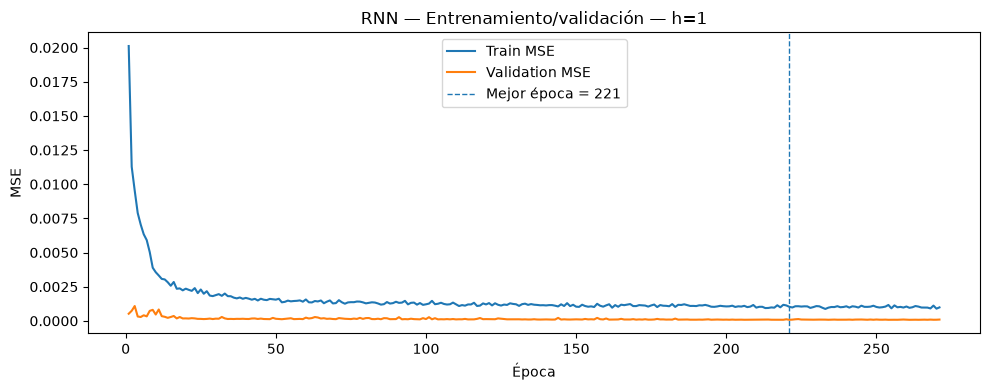

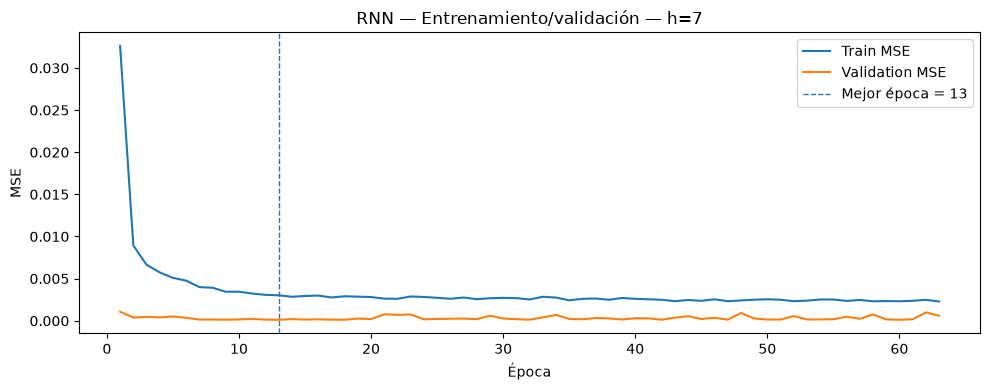

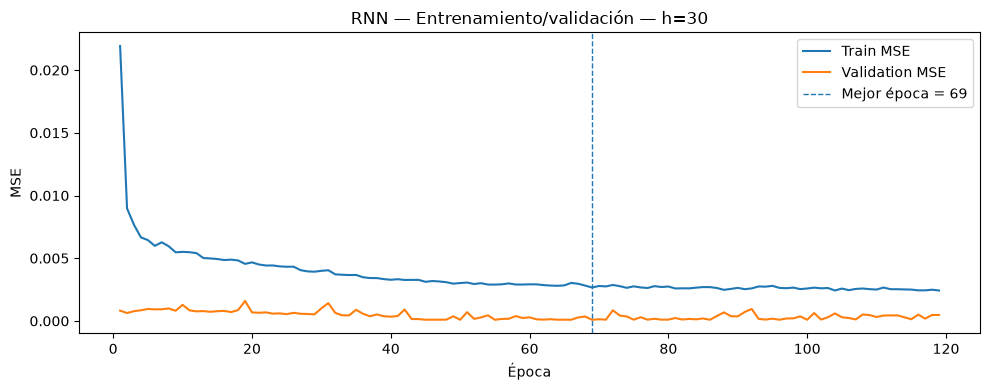

In [16]:
# ============================================================
# 10. CURVAS DE VALIDACIÓN
# ============================================================

for horizonte in [1, 7, 30]:

    info = modelos_finales[horizonte]

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        range(1, len(info["hist_train"]) + 1),
        info["hist_train"],
        label="Train MSE"
    )

    ax.plot(
        range(1, len(info["hist_val"]) + 1),
        info["hist_val"],
        label="Validation MSE"
    )

    ax.axvline(
        info["best_epoch"],
        linestyle="--",
        linewidth=1,
        label=f"Mejor época = {info['best_epoch']}"
    )

    ax.set_xlabel("Época")
    ax.set_ylabel("MSE")
    ax.set_title(
        f"RNN — Entrenamiento/validación — h={horizonte}"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

## Backtesting walk-forward

El modelo se entrena una sola vez por horizonte.

Para cada bloque del test:

1. usa únicamente la historia real disponible hasta el origen del pronóstico;
2. recibe las covariables observadas del bloque futuro;
3. produce directamente todo el bloque;
4. después se incorporan las observaciones reales al contexto;
5. continúa con el bloque siguiente.

No se reentrena durante el walk-forward.

In [17]:
# ============================================================
# 11. FORECAST DE BLOQUE Y WALK-FORWARD
# ============================================================

def forecast_bloque_directo(
    modelo,
    contexto_real,
    exog_futuras_reales,
    scaler_y,
    scaler_x,
    ventana,
    horizonte
):

    if len(contexto_real) < ventana:
        raise ValueError(
            "No hay suficiente historia para construir la ventana."
        )

    hist = contexto_real.iloc[-ventana:].copy()

    hist_scaled = hist.copy()
    hist_scaled[TARGET] = scaler_y.transform(
        hist[[TARGET]]
    ).ravel()

    hist_scaled[COVARIABLES] = scaler_x.transform(
        hist[COVARIABLES]
    )

    fut = exog_futuras_reales[COVARIABLES].copy()

    if len(fut) == 0:
        raise ValueError(
            "El bloque de covariables futuras está vacío."
        )

    # Último bloque parcial
    if len(fut) < horizonte:
        ultima = fut.iloc[[-1]].copy()
        faltan = horizonte - len(fut)

        fut = pd.concat(
            [fut]
            + [ultima.copy() for _ in range(faltan)],
            ignore_index=True
        )

    fut = fut.iloc[:horizonte]

    fut_scaled = scaler_x.transform(
        fut[COVARIABLES]
    )

    xh = torch.tensor(
        hist_scaled[FEATURES_HIST]
        .values
        .astype(np.float32)
    ).unsqueeze(0).to(device)

    xf = torch.tensor(
        fut_scaled.astype(np.float32)
    ).unsqueeze(0).to(device)

    modelo.eval()

    with torch.no_grad():
        pred_scaled = (
            modelo(xh, xf)
            .cpu()
            .numpy()
            .reshape(-1, 1)
        )

    pred = scaler_y.inverse_transform(
        pred_scaled
    ).ravel()

    return pred


def walk_forward_rnn_directo(
    modelo,
    train_real,
    test_real,
    scaler_y,
    scaler_x,
    ventana,
    horizonte
):

    predicciones = []
    fechas_pred = []

    contexto = train_real.copy()

    for i in range(0, len(test_real), horizonte):

        bloque = test_real.iloc[
            i:i+horizonte
        ].copy()

        pasos_bloque = len(bloque)

        pred_h = forecast_bloque_directo(
            modelo=modelo,
            contexto_real=contexto,
            exog_futuras_reales=bloque[COVARIABLES],
            scaler_y=scaler_y,
            scaler_x=scaler_x,
            ventana=ventana,
            horizonte=horizonte
        )

        predicciones.extend(
            pred_h[:pasos_bloque]
        )

        fechas_pred.extend(
            bloque.index
        )

        # Se incorporan valores REALES después del bloque.
        contexto = pd.concat(
            [contexto, bloque],
            axis=0
        )

    return pd.Series(
        predicciones,
        index=pd.DatetimeIndex(fechas_pred)
    )

In [18]:
# ============================================================
# 12. MÉTRICAS COMUNES
# ============================================================

def calcular_metricas(real, pred):

    real = np.asarray(real, dtype=float)
    pred = np.asarray(pred, dtype=float)

    mae = np.mean(
        np.abs(real - pred)
    )

    rmse = np.sqrt(
        np.mean((real - pred) ** 2)
    )

    mask_mape = real != 0

    mape = (
        np.mean(
            np.abs(
                (real[mask_mape] - pred[mask_mape])
                / real[mask_mape]
            )
        ) * 100
        if mask_mape.any()
        else np.nan
    )

    den = np.abs(real) + np.abs(pred)
    mask_smape = den != 0

    smape = (
        np.mean(
            2
            * np.abs(
                real[mask_smape]
                - pred[mask_smape]
            )
            / den[mask_smape]
        ) * 100
        if mask_smape.any()
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": smape,
        "R²": r2_score(real, pred),
        "MedAE": median_absolute_error(real, pred),
        "MaxError": max_error(real, pred),
        "Sesgo": np.mean(pred - real)
    }


def agregar_metricas(
    nombre,
    real,
    pred,
    archivo,
    horizonte
):

    metricas = calcular_metricas(
        real,
        pred
    )

    nueva_fila = pd.DataFrame([{
        "Modelo": nombre,
        "Horizonte": horizonte,
        "MAE": round(metricas["MAE"], 2),
        "RMSE": round(metricas["RMSE"], 2),
        "MAPE (%)": round(metricas["MAPE (%)"], 2),
        "sMAPE (%)": round(metricas["sMAPE (%)"], 2),
        "R²": round(metricas["R²"], 4),
        "MedAE": round(metricas["MedAE"], 2),
        "MaxError": round(metricas["MaxError"], 2),
        "Sesgo": round(metricas["Sesgo"], 2)
    }])

    if archivo.exists():

        tabla = pd.read_parquet(
            archivo
        )

        tabla = tabla[
            ~(
                (tabla["Modelo"] == nombre)
                & (tabla["Horizonte"] == horizonte)
            )
        ]

        tabla = pd.concat(
            [tabla, nueva_fila],
            ignore_index=True
        )

    else:
        tabla = nueva_fila

    tabla.to_parquet(
        archivo,
        index=False
    )

    print(
        f"'{nombre}' (horizonte={horizonte}d) "
        f"guardado en {archivo}"
    )

    return tabla

In [19]:
# ============================================================
# 13. EVALUACIÓN WALK-FORWARD: H = 1, 7, 30
# ============================================================

resultados_horizonte = {}

for horizonte in [1, 7, 30]:

    info = modelos_finales[horizonte]
    cfg = info["config"]

    print("\n" + "=" * 80)
    print(
        f"BACKTEST RNN DIRECTA — H={horizonte}"
    )
    print("=" * 80)

    pred = walk_forward_rnn_directo(
        modelo=info["modelo"],
        train_real=train,
        test_real=test,
        scaler_y=info["scaler_y"],
        scaler_x=info["scaler_x"],
        ventana=int(cfg["ventana"]),
        horizonte=horizonte
    )

    real = test.loc[
        pred.index,
        TARGET
    ]

    metricas = calcular_metricas(
        real,
        pred
    )

    print(
        f"MAE={metricas['MAE']:.2f} | "
        f"RMSE={metricas['RMSE']:.2f} | "
        f"MAPE={metricas['MAPE (%)']:.2f}% | "
        f"R²={metricas['R²']:.4f}"
    )

    agregar_metricas(
        nombre="RNN_Directa",
        real=real,
        pred=pred,
        archivo=archivo_tabla,
        horizonte=horizonte
    )

    resultados_horizonte[horizonte] = {
        "pred": pred,
        "real": real,
        "metricas": metricas
    }


resumen_rnn = pd.DataFrame([
    {
        "Horizonte": h,
        **resultados_horizonte[h]["metricas"]
    }
    for h in [1, 7, 30]
])

display(resumen_rnn)


BACKTEST RNN DIRECTA — H=1
MAE=57.46 | RMSE=82.74 | MAPE=17.43% | R²=0.8471
'RNN_Directa' (horizonte=1d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet

BACKTEST RNN DIRECTA — H=7
MAE=148.21 | RMSE=222.69 | MAPE=35.52% | R²=-0.1072
'RNN_Directa' (horizonte=7d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet

BACKTEST RNN DIRECTA — H=30
MAE=162.76 | RMSE=254.79 | MAPE=38.84% | R²=-0.4494
'RNN_Directa' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


,Horizonte,MAE,RMSE,MAPE (%),sMAPE (%),R²,MedAE,MaxError,Sesgo
0,1,57.457477,82.744006,17.434326,18.573113,0.847138,36.648531,328.476375,-34.879234
1,7,148.207628,222.694585,35.518622,45.380212,-0.107248,77.686220,676.875026,-132.898341
2,30,162.760668,254.789332,38.839754,50.414791,-0.449400,71.073328,777.366666,-137.089074


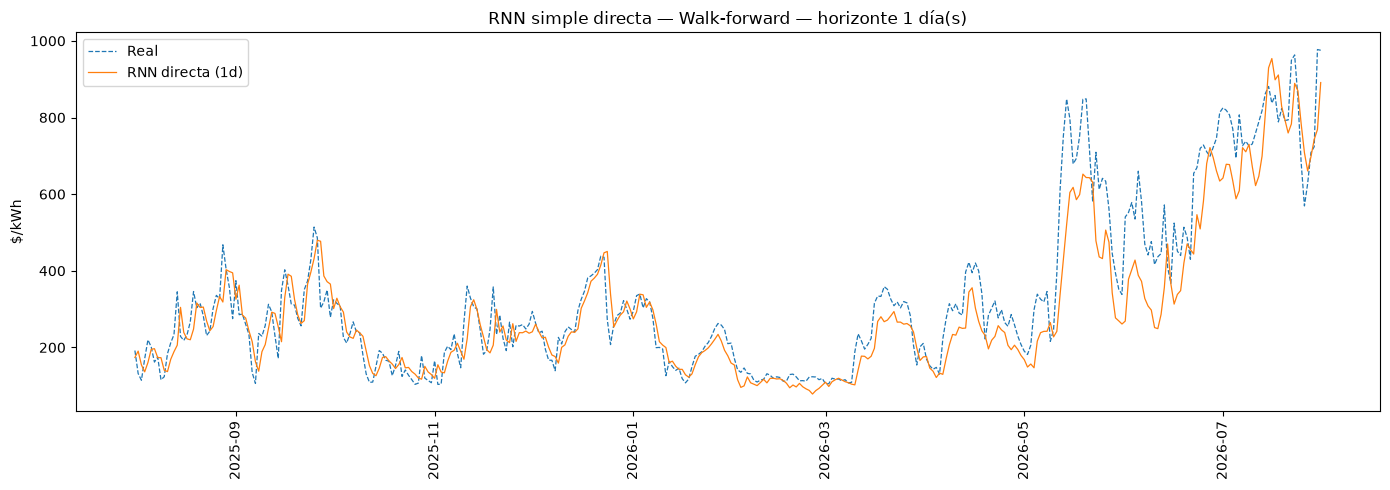

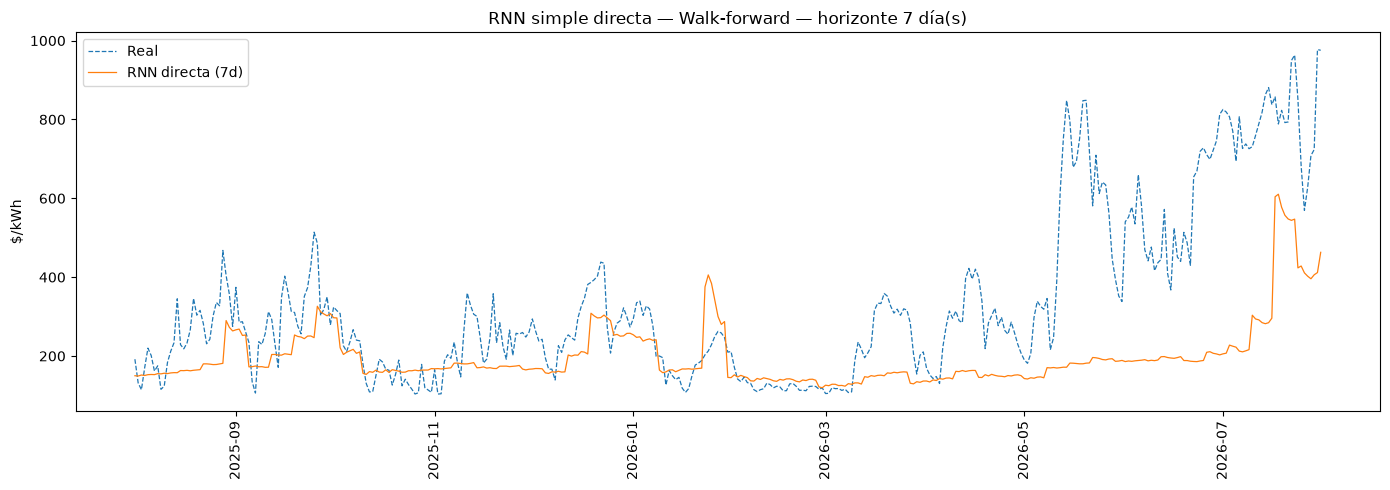

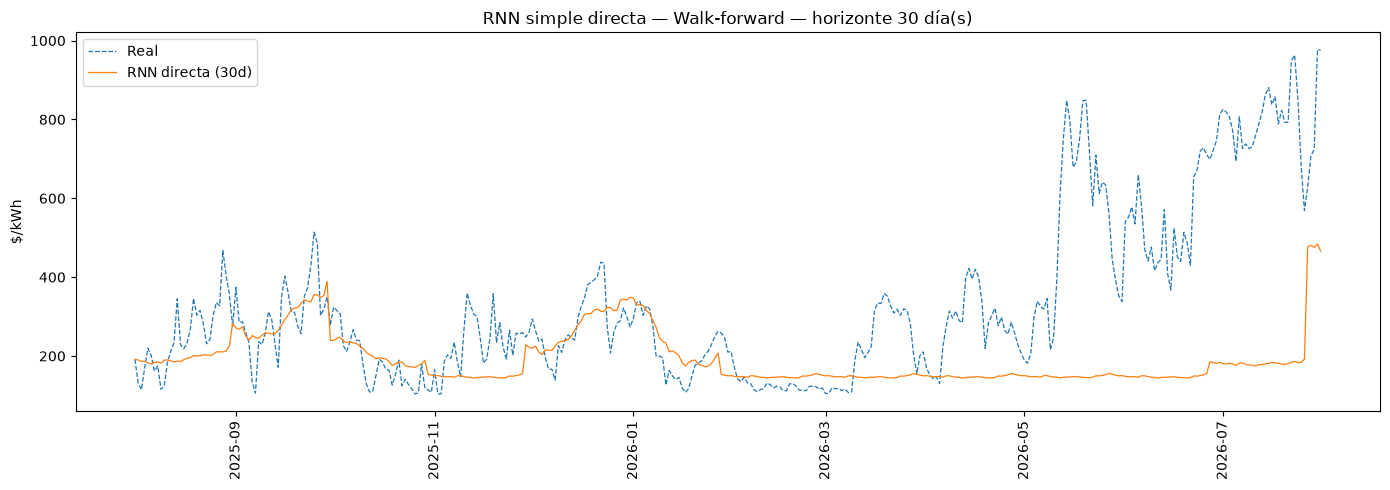

In [20]:
# ============================================================
# 14. GRÁFICOS REAL VS. PRONÓSTICO
# ============================================================

for horizonte in [1, 7, 30]:

    real = resultados_horizonte[horizonte]["real"]
    pred = resultados_horizonte[horizonte]["pred"]

    fig, ax = plt.subplots(
        figsize=(14, 5)
    )

    ax.plot(
        real.index,
        real.values,
        linewidth=0.9,
        linestyle="--",
        label="Real"
    )

    ax.plot(
        pred.index,
        pred.values,
        linewidth=0.9,
        label=f"RNN directa ({horizonte}d)"
    )

    ax.set_ylabel("$/kWh")
    ax.tick_params(
        axis="x",
        rotation=90
    )

    ax.legend()

    ax.set_title(
        f"RNN simple directa — "
        f"Walk-forward — horizonte {horizonte} día(s)"
    )

    plt.tight_layout()
    plt.show()

## Diagnóstico específico del horizonte 30

Se calcula el MAE promedio por posición dentro de cada bloque de 30 días. Esto permite ver si la red pierde precisión conforme aumenta la distancia respecto al origen del pronóstico.

,paso_en_bloque,MAE
0,1,102.517010
1,2,125.929718
2,3,120.255772
3,4,130.929057
4,5,136.129001
5,6,106.718865
6,7,124.083315
7,8,126.060641
8,9,130.330764
9,10,137.246400


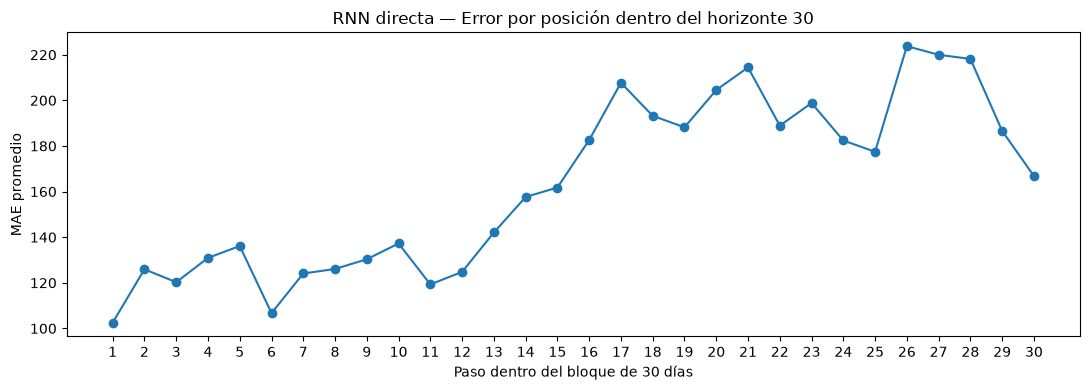

In [21]:
# ============================================================
# 15. ERROR POR PASO DENTRO DEL HORIZONTE 30
# ============================================================

pred30 = resultados_horizonte[30]["pred"]
real30 = resultados_horizonte[30]["real"]

diag30 = pd.DataFrame({
    "fecha": pred30.index,
    "real": real30.values,
    "pred": pred30.values
})

diag30["error"] = (
    diag30["pred"]
    - diag30["real"]
)

diag30["error_abs"] = np.abs(
    diag30["error"]
)

diag30["paso_en_bloque"] = (
    np.arange(len(diag30)) % 30
) + 1

mae_por_paso = (
    diag30
    .groupby("paso_en_bloque")["error_abs"]
    .mean()
    .rename("MAE")
    .reset_index()
)

display(mae_por_paso)

fig, ax = plt.subplots(
    figsize=(11, 4)
)

ax.plot(
    mae_por_paso["paso_en_bloque"],
    mae_por_paso["MAE"],
    marker="o"
)

ax.set_xlabel(
    "Paso dentro del bloque de 30 días"
)

ax.set_ylabel(
    "MAE promedio"
)

ax.set_title(
    "RNN directa — Error por posición dentro del horizonte 30"
)

ax.set_xticks(
    range(1, 31)
)

plt.tight_layout()
plt.show()

## Pronóstico genuinamente futuro — 30 días

Se utiliza exclusivamente el modelo entrenado para `h=30`.

Para conservar la comparabilidad con el esquema utilizado en NBEATSx:

- `gen_termica`: promedio histórico del mismo día calendario;
- `aportes_energia_gwh`: promedio histórico del mismo día calendario;
- `ONI`: trayectoria lineal desde un valor inicial hasta el punto medio de una categoría de escenario.

> La columna que alimenta el modelo continúa llamándose `ONI`. Si el escenario construido corresponde conceptualmente a RONI, esa equivalencia debe documentarse en la metodología.

In [22]:
# ============================================================
# 16. COVARIABLES FUTURAS — AGOSTO 2026
# ============================================================

fechas_futuras = pd.date_range(
    test.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

# Misma lógica de escenario usada en notebooks anteriores.
ONI_ESCENARIO_INICIAL = 1.0
CATEGORIA_OUTLOOK = "muy_fuerte"

PUNTOS_MEDIOS_CATEGORIA = {
    "debil": 0.7,
    "moderado": 1.2,
    "fuerte": 1.7,
    "muy_fuerte": 2.3
}

oni_objetivo = (
    PUNTOS_MEDIOS_CATEGORIA[
        CATEGORIA_OUTLOOK
    ]
)

oni_futuro = np.linspace(
    ONI_ESCENARIO_INICIAL,
    oni_objetivo,
    len(fechas_futuras)
)

gen_termica_futuro = []
aportes_futuro = []

for fecha in fechas_futuras:

    mismo_dia = df_modelo[
        (df_modelo.index.month == fecha.month)
        & (df_modelo.index.day == fecha.day)
        & (df_modelo.index < fechas_futuras[0])
    ]

    gen_termica_futuro.append(
        mismo_dia["gen_termica"].mean()
    )

    aportes_futuro.append(
        mismo_dia["aportes_energia_gwh"].mean()
    )

exog_futuro = pd.DataFrame(
    {
        "gen_termica": gen_termica_futuro,
        "ONI": oni_futuro,
        "aportes_energia_gwh": aportes_futuro
    },
    index=fechas_futuras
)

for col in [
    "gen_termica",
    "aportes_energia_gwh"
]:
    if exog_futuro[col].isna().any():
        exog_futuro[col] = (
            exog_futuro[col]
            .fillna(train[col].mean())
        )

display(exog_futuro.head())

,gen_termica,ONI,aportes_energia_gwh
2026-08-01,3.617576e+07,1.000000,3.634529e+08
2026-08-02,3.543778e+07,1.044828,3.796149e+08
2026-08-03,3.552428e+07,1.089655,3.634027e+08
2026-08-04,3.551402e+07,1.134483,3.491337e+08
2026-08-05,3.627920e+07,1.179310,3.637855e+08


Forecast RNN directa: 2026-08-01 → 2026-08-30


,RNN_Directa
2026-08-01,277.210297
2026-08-02,202.303467
2026-08-03,280.713898
2026-08-04,252.769363
2026-08-05,282.077820
2026-08-06,290.417419
2026-08-07,300.683685
2026-08-08,368.765656
2026-08-09,365.082001
2026-08-10,419.026825


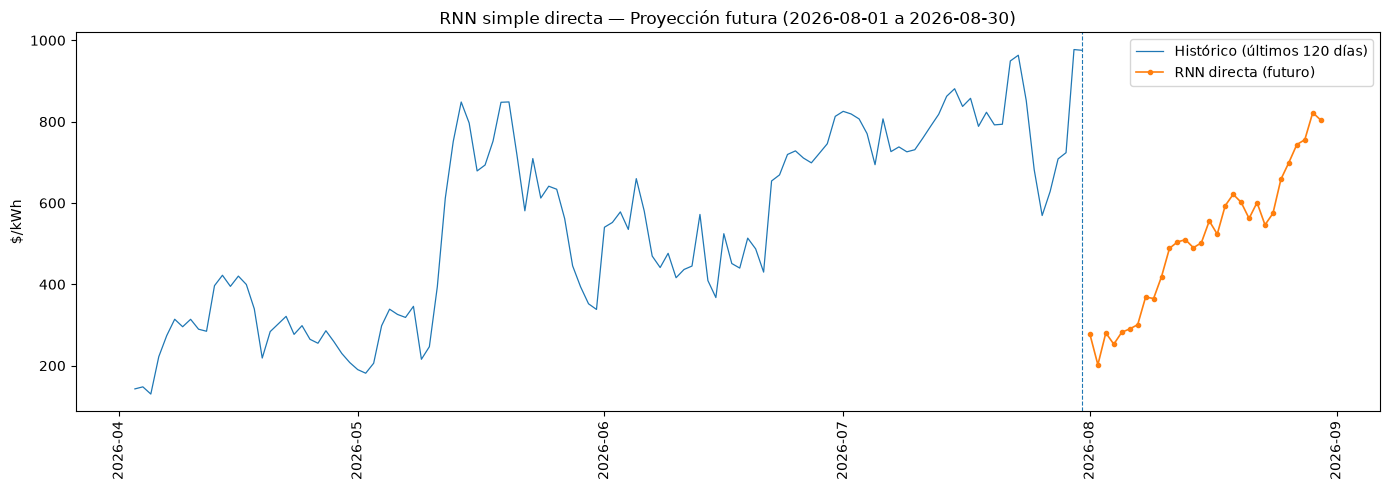

In [23]:
# ============================================================
# 17. FORECAST FUTURO CON EL MODELO h=30
# ============================================================

info30 = modelos_finales[30]
cfg30 = info30["config"]

contexto_completo = pd.concat(
    [train, test],
    axis=0
)

pred_futuro_30 = forecast_bloque_directo(
    modelo=info30["modelo"],
    contexto_real=contexto_completo,
    exog_futuras_reales=exog_futuro,
    scaler_y=info30["scaler_y"],
    scaler_x=info30["scaler_x"],
    ventana=int(cfg30["ventana"]),
    horizonte=30
)

forecast_futuro_rnn = pd.Series(
    pred_futuro_30,
    index=fechas_futuras,
    name="RNN_Directa"
)

print(
    f"Forecast RNN directa: "
    f"{fechas_futuras[0].date()} → "
    f"{fechas_futuras[-1].date()}"
)

display(
    forecast_futuro_rnn.to_frame()
)


serie_completa = pd.concat(
    [train[TARGET], test[TARGET]]
)

contexto_reciente = (
    serie_completa.iloc[-120:]
)

fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.plot(
    contexto_reciente.index,
    contexto_reciente.values,
    linewidth=0.9,
    label="Histórico (últimos 120 días)"
)

ax.plot(
    forecast_futuro_rnn.index,
    forecast_futuro_rnn.values,
    linewidth=1.2,
    marker="o",
    markersize=3,
    label="RNN directa (futuro)"
)

ax.axvline(
    serie_completa.index[-1],
    linestyle="--",
    linewidth=0.8
)

ax.set_ylabel("$/kWh")
ax.tick_params(
    axis="x",
    rotation=90
)

ax.legend()

ax.set_title(
    f"RNN simple directa — Proyección futura "
    f"({fechas_futuras[0].date()} a "
    f"{fechas_futuras[-1].date()})"
)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 18. GUARDAR FORECAST Y CONFIGURACIONES
# ============================================================

forecast_futuro_rnn.to_frame().to_csv(
    BASE / "forecast_futuro_RNN_Directa_h30.csv",
    index_label="fecha"
)

configs_guardar = {}

for h, info in modelos_finales.items():

    cfg = dict(info["config"])
    cfg_limpia = {}

    for k, v in cfg.items():

        if isinstance(v, np.integer):
            v = int(v)

        elif isinstance(v, np.floating):
            v = float(v)

        cfg_limpia[k] = v

    cfg_limpia["best_epoch_final"] = int(
        info["best_epoch"]
    )

    cfg_limpia["val_mse_final"] = float(
        info["val_mse"]
    )

    configs_guardar[str(h)] = cfg_limpia

with open(
    MODELS_DIR / "rnn_direct_configuraciones.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        configs_guardar,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    "Modelos, scalers, tuning, forecast "
    "y configuraciones guardados."
)

Modelos, scalers, tuning, forecast y configuraciones guardados.


## Lectura metodológica del experimento

Este modelo permite responder una pregunta adicional frente a LSTM y GRU:

> **¿Una RNN simple, entrenada específicamente para producir de forma conjunta todo el horizonte y utilizando información exógena futura, puede evitar parte de la degradación observada en los pronósticos recursivos de 30 días?**

Si el desempeño a 30 días mejora, no debe atribuirse únicamente al cambio de celda recurrente. También cambia la **estrategia de forecasting**, de recursiva a directa multisalida. Esa diferencia debe considerarse al interpretar los resultados.